# Cross-Validation with the Heathrow Weather Dataset

**MST374 — Condensed tutorial notebook**

---

This notebook brings together the essential cross-validation material from Computer sessions 10SML.3, demonstrating:

1. Loading and splitting the Heathrow weather dataset
2. **5-fold cross-validation** to estimate model performance
3. **Cross-validation for hyperparameter tuning** — choosing the number of hidden-layer nodes
4. Final model training and test-set evaluation

All code is self-contained; run the cells in order.

## 1. Imports

In [3]:
import os
os.environ['TF_DISABLE_MPS'] = '1'       # disable Metal GPU — run on CPU
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # hide any CUDA devices too

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, KFold

from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.utils import set_random_seed as keras_set_random_seed

# Suppress TensorFlow info/warning messages
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

## 2. Load the data

The dataset contains 1060 daily weather measurements recorded at Heathrow airport. Each row is one day; the first 11 columns are predictive features (year, month, day, cloud cover, precipitation amount, mean sea-level pressure, wind direction, maximum temperature, minimum temperature, sunshine hours, and radiation). The final column `Precipitation` is the binary outcome: 1 if precipitation occurred that day, 0 otherwise.

There are 566 positive cases (precipitation) and 494 negative cases in the full dataset.

In [5]:
dataset = pd.read_csv('heathrow_weather.csv')
print(dataset.shape)
dataset.head()

(1060, 12)


,Year,Month,Day,CloudCover,Humidity,AirPressure,Radiation,SunShine,Temp(mean),Temp(min),Temp(max),Precipitation
0,2000,1,1,7,94,1024.5,18,0.4,7.0,4.9,10.8,0
1,2000,1,2,7,89,1025.3,20,0.7,7.9,5.0,11.5,1
2,2000,1,3,8,91,1018.6,13,0.0,9.4,7.2,9.5,1
3,2000,1,4,5,89,1014.8,34,2.9,7.0,4.4,11.0,1
4,2000,1,5,5,85,1014.2,25,1.3,6.4,1.9,10.8,1


Extract predictive features and outcomes into NumPy arrays (required by Keras), then split into a **training set** (80 %) and a held-out **test set** (20 %).

The test set is set aside now and will only be touched once, at the very end, to give a fair estimate of the final model's performance.

In [7]:
X = dataset.iloc[:, :11].to_numpy()   # 11 predictive features
y = dataset['Precipitation'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=374
)

print('Training set size:', len(X_train))
print('Test set size:    ', len(X_test))
print()
print('Proportion positive in full dataset:', (y == 1).sum() / len(y))
print('Proportion positive in training set:', (y_train == 1).sum() / len(y_train))
print('Proportion positive in test set:    ', (y_test == 1).sum() / len(y_test))

Training set size: 848
Test set size:     212

Proportion positive in full dataset: 0.5339622641509434
Proportion positive in training set: 0.5306603773584906
Proportion positive in test set:     0.5471698113207547


## 3. Why cross-validation?

When we split the data once into training and test sets, our performance estimate depends on which particular cases ended up in the test set — a matter of chance. **$k$-fold cross-validation** reduces this variance by repeating the split $k$ times:

1. Divide the learning set into $k$ equal subsets (folds).
2. In turn, hold out each fold as the test set and train on the remaining $k-1$ folds.
3. Average the $k$ performance scores.

Every case is used for testing exactly once. The averaged score is a more reliable estimate of how the model will perform on genuinely unseen data.

Cross-validation is also the standard way to **tune hyperparameters** (e.g. number of hidden nodes) without peeking at the reserved test set.

## 4. The MLP architecture

Throughout this notebook we use the same network topology studied in Computer session 10SML.3:

- Input layer: 11 nodes (one per feature)
- Two hidden layers with ReLU activation
- Output layer: 1 node with sigmoid activation (gives a score in $(0,1)$)
- Optimiser: Adam; loss: binary cross-entropy

Because we will create the model multiple times (once per fold), we wrap the construction in a function `create_model(nodes)` that accepts the number of nodes in each hidden layer as an argument.

In [10]:
def create_model(nodes=5):
    """
    Build and compile a 2-hidden-layer MLP.

    Parameters
    ----------
    nodes : int
        Number of nodes in each of the two hidden layers.

    Returns
    -------
    A compiled Keras Sequential model.
    """
    model = Sequential()
    model.add(Input(shape=(11,)))
    model.add(Dense(activation='relu', units=nodes,
                    kernel_initializer='uniform', bias_initializer='uniform'))
    model.add(Dense(activation='relu', units=nodes,
                    kernel_initializer='uniform', bias_initializer='uniform'))
    model.add(Dense(activation='sigmoid', units=1,
                    kernel_initializer='uniform', bias_initializer='uniform'))
    model.compile(optimizer=Adam(), loss='binary_crossentropy',
                  metrics=['accuracy', 'AUC'])
    return model

## 5. Example 1 — 5-fold cross-validation (performance estimation)

We train the MLP (with 5 nodes per hidden layer) using 5-fold cross-validation on the **full learning set** `X` / `y`, running for 10 epochs per fold. The average accuracy and AUC-ROC over the five folds gives our estimate of how well this architecture generalises.

In [12]:
keras_set_random_seed(374)

# Generate the 5 index splits (shuffle so folds are not ordered by time)
splits = KFold(n_splits=5, shuffle=True, random_state=0).split(X)

accuracies = []
AUCs = []

for fold_number, split in enumerate(splits, start=1):
    print(f'Fold {fold_number}')

    X_train_fold = X[split[0]]
    y_train_fold = y[split[0]]
    X_test_fold  = X[split[1]]
    y_test_fold  = y[split[1]]

    model = create_model(nodes=5)
    model.fit(X_train_fold, y_train_fold, batch_size=10, epochs=10, verbose=0)

    loss, accuracy, AUC_ROC = model.evaluate(X_test_fold, y_test_fold, verbose=0)
    accuracies.append(accuracy)
    AUCs.append(AUC_ROC)
    print(f'  accuracy: {accuracy:.4f}   AUC-ROC: {AUC_ROC:.4f}')

print()
print(f'Average accuracy: {np.mean(accuracies):.4f}')
print(f'Average AUC-ROC : {np.mean(AUCs):.4f}')

Fold 1
  accuracy: 0.6509   AUC-ROC: 0.7187
Fold 2
  accuracy: 0.6321   AUC-ROC: 0.7039
Fold 3
  accuracy: 0.6321   AUC-ROC: 0.7271
Fold 4
  accuracy: 0.6179   AUC-ROC: 0.6495
Fold 5
  accuracy: 0.5802   AUC-ROC: 0.6151

Average accuracy: 0.6226
Average AUC-ROC : 0.6829


**What to notice:**
- Each fold gives a slightly different accuracy and AUC-ROC, reflecting the variance due to which cases happen to be in the test set.
- The *average* over the five folds is our best single estimate of model performance — more reliable than any one split.
- With only 10 epochs the scores are moderate; the model has not fully converged. That is fine here because the purpose of this CV run is comparison, not maximising performance.

## 6. Example 2 — Cross-validation for hyperparameter tuning

How many nodes should each hidden layer have — 5, 10, or 15? We use 5-fold cross-validation on the **training set** `X_train` / `y_train` to compare the three options. The test set `X_test` / `y_test` remains untouched until after we have made our choice.

Each fold trains for 50 epochs so that differences between architectures can emerge.

*Note: this cell may take a couple of minutes to run.*

In [15]:
keras_set_random_seed(374)

nodes_settings = [5, 10, 15]

accuracy_results = pd.DataFrame(columns=nodes_settings)
AUC_results      = pd.DataFrame(columns=nodes_settings)

# CV splits of the training set (NOT the full dataset)
splits = KFold(n_splits=5, shuffle=True, random_state=0).split(X_train)

for fold_number, split in enumerate(splits, start=1):
    print(f'\nFold {fold_number}')

    X_train_fold = X_train[split[0]]
    y_train_fold = y_train[split[0]]
    X_valid_fold = X_train[split[1]]
    y_valid_fold = y_train[split[1]]

    for nodes in nodes_settings:
        model = create_model(nodes)
        model.fit(X_train_fold, y_train_fold, batch_size=10, epochs=50, verbose=0)
        loss, accuracy, AUC_ROC = model.evaluate(X_valid_fold, y_valid_fold, verbose=0)

        accuracy_results.loc[f'Fold {fold_number}', nodes] = accuracy
        AUC_results.loc[f'Fold {fold_number}', nodes]      = AUC_ROC
        print(f'  nodes={nodes:2d}  accuracy={accuracy:.4f}  AUC-ROC={AUC_ROC:.4f}')

# Append row of means
accuracy_results.loc['Mean'] = accuracy_results.mean()
AUC_results.loc['Mean']      = AUC_results.mean()

print('\nAccuracy results')
display(accuracy_results)
print('\nAUC-ROC results')
display(AUC_results)


Fold 1
  nodes= 5  accuracy=0.6706  AUC-ROC=0.7407
  nodes=10  accuracy=0.6588  AUC-ROC=0.7398
  nodes=15  accuracy=0.6588  AUC-ROC=0.7553

Fold 2
  nodes= 5  accuracy=0.5706  AUC-ROC=0.6451
  nodes=10  accuracy=0.6118  AUC-ROC=0.6571
  nodes=15  accuracy=0.5882  AUC-ROC=0.6629

Fold 3
  nodes= 5  accuracy=0.6471  AUC-ROC=0.7119
  nodes=10  accuracy=0.6529  AUC-ROC=0.7076
  nodes=15  accuracy=0.6294  AUC-ROC=0.7040

Fold 4
  nodes= 5  accuracy=0.7337  AUC-ROC=0.7983
  nodes=10  accuracy=0.7337  AUC-ROC=0.7994
  nodes=15  accuracy=0.7574  AUC-ROC=0.8121

Fold 5
  nodes= 5  accuracy=0.5621  AUC-ROC=0.5000
  nodes=10  accuracy=0.6509  AUC-ROC=0.7195
  nodes=15  accuracy=0.5621  AUC-ROC=0.5000

Accuracy results


,5,10,15
Fold 1,0.670588,0.658824,0.658824
Fold 2,0.570588,0.611765,0.588235
Fold 3,0.647059,0.652941,0.629412
Fold 4,0.733728,0.733728,0.757396
Fold 5,0.56213,0.650888,0.56213
Mean,0.636819,0.661629,0.639199



AUC-ROC results


,5,10,15
Fold 1,0.740748,0.739771,0.755272
Fold 2,0.645067,0.657051,0.662904
Fold 3,0.711876,0.707625,0.704011
Fold 4,0.798263,0.799384,0.812132
Fold 5,0.5,0.719488,0.5
Mean,0.679191,0.724664,0.686864


The architecture with the highest mean AUC-ROC (and accuracy) over the five folds is our preferred choice. We can also visualise the comparison:

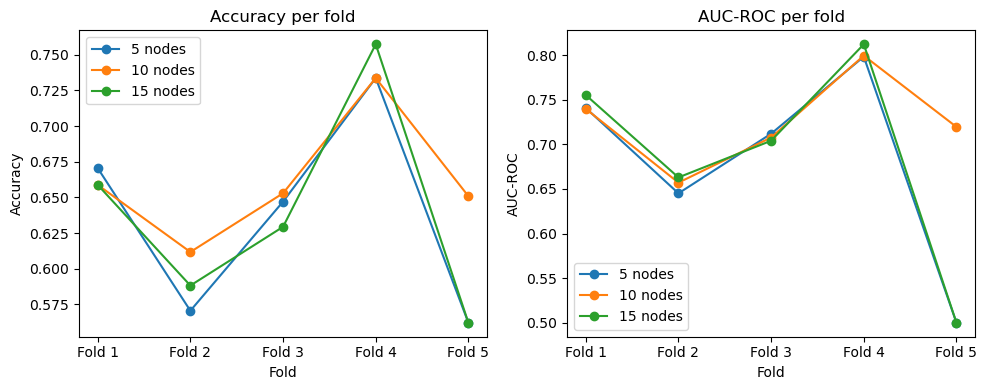

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fold_rows = [r for r in accuracy_results.index if r != 'Mean']

for nodes in nodes_settings:
    axes[0].plot(fold_rows, accuracy_results.loc[fold_rows, nodes].astype(float),
                 marker='o', label=f'{nodes} nodes')
    axes[1].plot(fold_rows, AUC_results.loc[fold_rows, nodes].astype(float),
                 marker='o', label=f'{nodes} nodes')

for ax, metric in zip(axes, ['Accuracy', 'AUC-ROC']):
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per fold')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Final model — train on full training set, test once

Having selected the best architecture from the cross-validation results above, we now train a fresh model with that architecture on the **entire training set** and evaluate it on the **held-out test set** — the first (and only) time the test set is used.

In [19]:
# Replace 10 below with whichever node count won in Section 6
best_nodes = 10

keras_set_random_seed(374)
final_model = create_model(best_nodes)
final_model.fit(X_train, y_train, batch_size=10, epochs=50, verbose=0)

loss, accuracy, AUC_ROC = final_model.evaluate(X_test, y_test, verbose=0)
print(f'Final model  ({best_nodes} nodes per hidden layer, 50 epochs)')
print(f'  Test-set accuracy : {accuracy:.4f}')
print(f'  Test-set AUC-ROC  : {AUC_ROC:.4f}')

Final model  (10 nodes per hidden layer, 50 epochs)
  Test-set accuracy : 0.6415
  Test-set AUC-ROC  : 0.7100


**Summary of what happened:**

| Stage | Data used | Purpose |
|-------|-----------|--------|
| Section 5 (CV performance) | Full learning set `X`/`y` | Estimate how well the 5-node architecture generalises |
| Section 6 (CV tuning) | Training set `X_train`/`y_train` | Choose best number of nodes without touching test data |
| Section 7 (final test) | Train on `X_train`, test on `X_test` | Single honest evaluation of the chosen model |

This workflow — CV for selection, single final test for reporting — is standard practice. It prevents the test score from being optimistically biased by the choices made during model development.

## Exercise

The cross-validation in Section 6 only considered 5, 10, and 15 nodes. Extend the search to include **20 and 25** nodes, keeping all other settings the same. Does the best architecture change?

*(Hint: just add `20` and `25` to the `nodes_settings` list in Section 6 and re-run.)*

In [22]:
# ✏️ Your answer here


---

## Acknowledgements

The Heathrow airport weather measurements are derived from the European Climate Assessment & Dataset project:
Klein Tank, A.M.G. and Coauthors, 2002. *Daily dataset of 20th-century surface air temperature and precipitation series for the European Climate Assessment.* Int. J. of Climatol., 22, 1441-1453.

Data and metadata available at [https://www.ecad.eu](https://www.ecad.eu).